# Proposal Charts (DEAD)

The two figures referenced as "suggested figures" in `DEAD_Proposal.docx`,
built here as actual charts. Self-contained -- rebuilds the weekly
event-flag pipeline from `caseb_calendar_events.ipynb` rather than
depending on that notebook having been run first.

1. **Figure 1** -- weekly statewide order volume over 2022-2026, with
   Super Bowl weeks and the Iowa State Fair annotated, plus a second panel
   comparing Iowa City / Ames volume against their home-game weeks.
2. **Figure 2** -- ranked horizontal bar chart of estimated % lift in
   weekly ordering by event and geography, color-coded by statistical
   significance.

In [1]:
import duckdb as db
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import statsmodels.api as sm

con = db.connect()

## Rebuild the weekly series and event calendar

Same logic as `caseb_calendar_events.ipynb`: weekly (Mon-Sun) aggregation
statewide and for Iowa City / Ames, because `ordered_on` reflects wholesale
restocking dates rather than point-of-sale dates.

In [2]:
def weekly_series(where_clause=""):
    query = f"""
        SELECT ordered_on, SUM(TRY_CAST(sales_bottles AS DOUBLE)) AS total_bottles
        FROM 'liquor_2022_2026.parquet'
        {where_clause}
        GROUP BY ordered_on
    """
    daily = con.execute(query).df()
    daily["ordered_on"] = pd.to_datetime(daily["ordered_on"])
    daily["week"] = daily["ordered_on"].dt.to_period("W-SUN")
    weekly = daily.groupby("week")["total_bottles"].sum().reset_index()
    weekly["week_start"] = weekly["week"].dt.start_time
    return weekly[
        (weekly["week_start"] >= "2022-01-03") & (weekly["week_start"] <= "2026-08-24")
    ].reset_index(drop=True)


weekly_state = weekly_series()
weekly_iowacity = weekly_series("WHERE store_city = 'IOWA CITY'")
weekly_ames = weekly_series("WHERE store_city = 'AMES'")

print(f"{len(weekly_state)} weeks, {weekly_state['week_start'].min().date()} to {weekly_state['week_start'].max().date()}")

243 weeks, 2022-01-03 to 2026-08-24


In [3]:
def nth_weekday(year, month, weekday, n):
    first = pd.Timestamp(year=year, month=month, day=1)
    return first + pd.Timedelta(days=(weekday - first.weekday()) % 7 + 7 * (n - 1))


def last_weekday(year, month, weekday):
    month_end = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
    return month_end - pd.Timedelta(days=(month_end.weekday() - weekday) % 7)


events = {}


def add_event(date, name):
    events.setdefault(pd.Timestamp(date), []).append(name)


SUPER_BOWL_SUNDAY = {
    2022: "2022-02-13", 2023: "2023-02-12", 2024: "2024-02-11",
    2025: "2025-02-09", 2026: "2026-02-08",
}
IOWA_STATE_FAIR = {
    2022: ("2022-08-11", "2022-08-21"), 2023: ("2023-08-10", "2023-08-20"),
    2024: ("2024-08-08", "2024-08-18"), 2025: ("2025-08-07", "2025-08-17"),
    2026: ("2026-08-13", "2026-08-23"),
}
HAWKEYES_HOME = {
    2022: ["2022-09-03", "2022-09-10", "2022-09-17", "2022-10-01", "2022-10-29", "2022-11-12", "2022-11-25"],
    2023: ["2023-09-02", "2023-09-16", "2023-09-30", "2023-10-07", "2023-10-21", "2023-11-11", "2023-11-18"],
    2024: ["2024-08-31", "2024-09-07", "2024-09-14", "2024-10-12", "2024-10-26", "2024-11-02", "2024-11-29"],
    2025: ["2025-08-30", "2025-09-13", "2025-09-27", "2025-10-18", "2025-10-25", "2025-11-08", "2025-11-22"],
    2026: ["2026-09-05"],
}
CYCLONES_HOME = {
    2022: ["2022-09-03", "2022-09-17", "2022-09-24", "2022-10-08", "2022-10-29", "2022-11-05", "2022-11-19"],
    2023: ["2023-09-02", "2023-09-09", "2023-09-23", "2023-10-07", "2023-11-04", "2023-11-18"],
    2024: ["2024-08-31", "2024-09-21", "2024-10-05", "2024-10-19", "2024-11-02", "2024-11-09", "2024-11-16"],
    2025: ["2025-08-30", "2025-09-06", "2025-09-27", "2025-10-25", "2025-11-01", "2025-11-22"],
    2026: ["2026-09-05", "2026-09-12"],
}

for year in range(2022, 2027):
    add_event(f"{year}-01-01", "New Year's Day")
    add_event(f"{year}-12-31", "New Year's Eve")
    add_event(SUPER_BOWL_SUNDAY[year], "Super Bowl Sunday")
    add_event(f"{year}-03-17", "St. Patrick's Day")
    add_event(f"{year}-05-05", "Cinco de Mayo")
    add_event(last_weekday(year, 5, 0), "Memorial Day")
    add_event(f"{year}-07-04", "July 4th")
    add_event(nth_weekday(year, 9, 0, 1), "Labor Day")
    add_event(f"{year}-10-31", "Halloween")
    thanksgiving = nth_weekday(year, 11, 3, 4)
    add_event(thanksgiving, "Thanksgiving")
    add_event(thanksgiving - pd.Timedelta(days=1), "Thanksgiving")
    add_event(f"{year}-12-24", "Christmas")
    add_event(f"{year}-12-25", "Christmas")

    fair_start, fair_end = IOWA_STATE_FAIR[year]
    for day in pd.date_range(fair_start, fair_end):
        add_event(day, "Iowa State Fair")

for date in [d for season in HAWKEYES_HOME.values() for d in season]:
    add_event(date, "Hawkeyes Home Game")
for date in [d for season in CYCLONES_HOME.values() for d in season]:
    add_event(date, "Cyclones Home Game")

events_df = pd.DataFrame(
    [(date, names) for date, names in sorted(events.items())], columns=["date", "events"]
)
events_df["week"] = events_df["date"].dt.to_period("W-SUN")

EVENT_TYPES = [
    "New Year's Day", "New Year's Eve", "Super Bowl Sunday", "St. Patrick's Day",
    "Cinco de Mayo", "Memorial Day", "July 4th", "Labor Day", "Halloween",
    "Thanksgiving", "Christmas", "Iowa State Fair",
]

print(f"{len(events_df)} event-dates, {events_df['week'].nunique()} distinct weeks touched")

164 event-dates, 95 distinct weeks touched


## Fit the models (needed for Figure 2)

In [4]:
def build_week_flags(weekly_df, extra_event=None):
    out = weekly_df.copy()
    for event_type in EVENT_TYPES:
        weeks_with_event = set(
            events_df.loc[events_df["events"].apply(lambda lst: event_type in lst), "week"]
        )
        out[event_type] = out["week"].isin(weeks_with_event).astype(int)

    if extra_event is not None:
        event_name, col_name = extra_event
        weeks_with_event = set(
            events_df.loc[events_df["events"].apply(lambda lst: event_name in lst), "week"]
        )
        out[col_name] = out["week"].isin(weeks_with_event).astype(int)

    out["t"] = range(len(out))
    out["month"] = out["week_start"].dt.month
    out["log_bottles"] = np.log1p(out["total_bottles"])
    return out


def fit_event_model(df, event_cols):
    d = pd.get_dummies(df, columns=["month"], drop_first=True)
    month_cols = [c for c in d.columns if c.startswith("month_")]
    X = sm.add_constant(d[["t"] + month_cols + event_cols].astype(float))
    y = d["log_bottles"].astype(float)
    return sm.OLS(y, X).fit()


def event_results_table(model, event_cols):
    return pd.DataFrame({
        "pct_lift": (np.exp(model.params[event_cols]) - 1) * 100,
        "p_value": model.pvalues[event_cols],
    })


weekly_state_f = build_week_flags(weekly_state)
weekly_iowacity_f = build_week_flags(weekly_iowacity, ("Hawkeyes Home Game", "home_game"))
weekly_ames_f = build_week_flags(weekly_ames, ("Cyclones Home Game", "home_game"))

model_state = fit_event_model(weekly_state_f, EVENT_TYPES)
model_iowacity = fit_event_model(weekly_iowacity_f, EVENT_TYPES + ["home_game"])
model_ames = fit_event_model(weekly_ames_f, EVENT_TYPES + ["home_game"])

results_state = event_results_table(model_state, EVENT_TYPES)
results_iowacity = event_results_table(model_iowacity, EVENT_TYPES + ["home_game"])
results_ames = event_results_table(model_ames, EVENT_TYPES + ["home_game"])

print(f"R-squared -- statewide: {model_state.rsquared:.3f}, "
      f"Iowa City: {model_iowacity.rsquared:.3f}, Ames: {model_ames.rsquared:.3f}")

R-squared -- statewide: 0.428, Iowa City: 0.332, Ames: 0.439


## Figure 1: weekly order volume, with events annotated

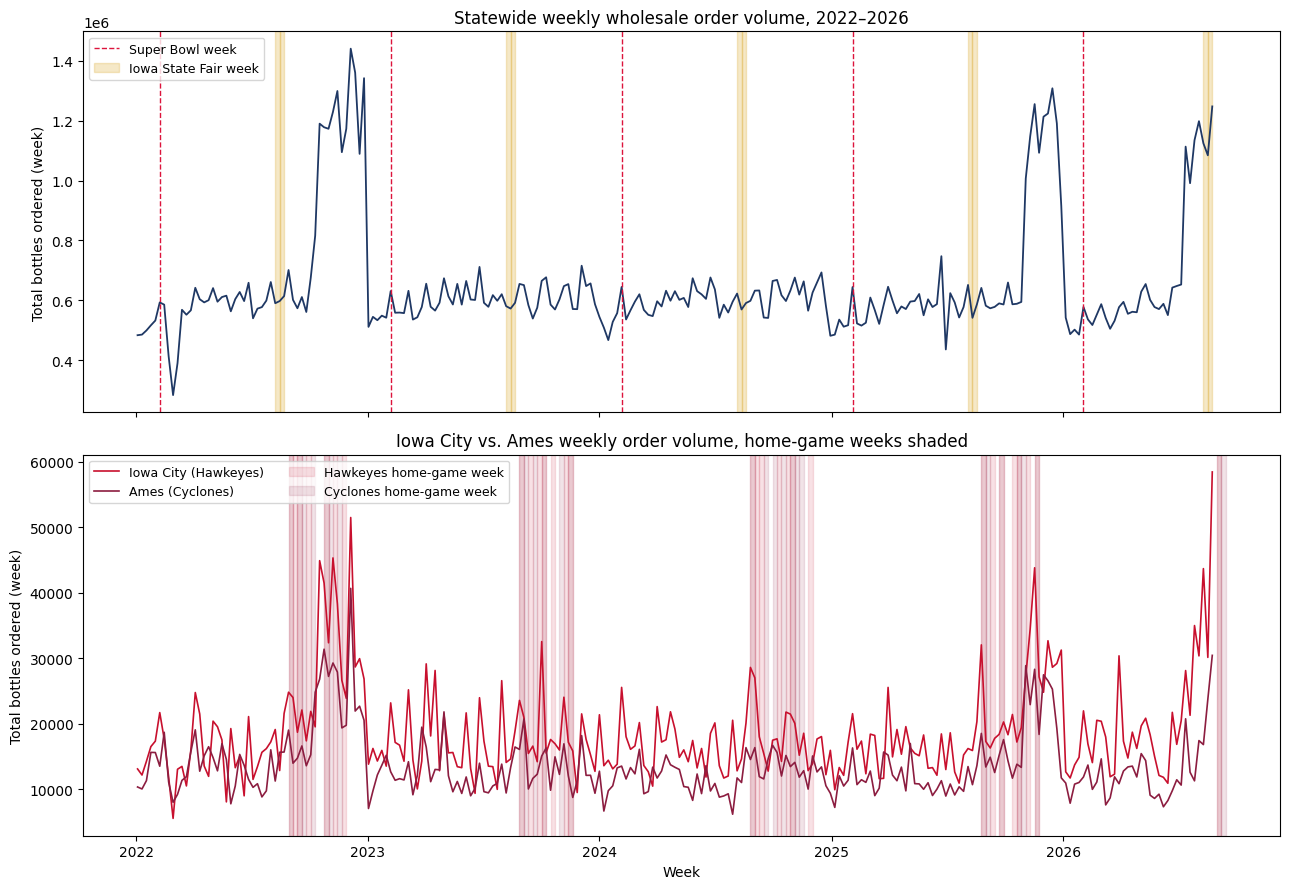

In [5]:
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# --- Top panel: statewide volume, Super Bowl + Iowa State Fair annotated ---
ax_top.plot(weekly_state["week_start"], weekly_state["total_bottles"],
            color="#1f3864", linewidth=1.3)

super_bowl_weeks = sorted({w.start_time for w in events_df.loc[
    events_df["events"].apply(lambda lst: "Super Bowl Sunday" in lst), "week"
]})
for i, wk in enumerate(super_bowl_weeks):
    ax_top.axvline(wk, color="crimson", linestyle="--", linewidth=1,
                   label="Super Bowl week" if i == 0 else None)

fair_weeks = sorted({w.start_time for w in events_df.loc[
    events_df["events"].apply(lambda lst: "Iowa State Fair" in lst), "week"
]})
for i, wk in enumerate(fair_weeks):
    ax_top.axvspan(wk, wk + pd.Timedelta(days=7), color="goldenrod", alpha=0.25,
                   label="Iowa State Fair week" if i == 0 else None)

ax_top.set_title("Statewide weekly wholesale order volume, 2022–2026")
ax_top.set_ylabel("Total bottles ordered (week)")
ax_top.legend(loc="upper left", fontsize=9)

# --- Bottom panel: Iowa City vs. Ames, home-game weeks shaded ---
ax_bottom.plot(weekly_iowacity["week_start"], weekly_iowacity["total_bottles"],
               color="#c8102e", linewidth=1.2, label="Iowa City (Hawkeyes)")
ax_bottom.plot(weekly_ames["week_start"], weekly_ames["total_bottles"],
               color="#8c1d40", linewidth=1.2, label="Ames (Cyclones)")

hawkeyes_weeks = sorted({w.start_time for w in events_df.loc[
    events_df["events"].apply(lambda lst: "Hawkeyes Home Game" in lst), "week"
]})
for i, wk in enumerate(hawkeyes_weeks):
    ax_bottom.axvspan(wk, wk + pd.Timedelta(days=7), color="#c8102e", alpha=0.12,
                       label="Hawkeyes home-game week" if i == 0 else None)

cyclones_weeks = sorted({w.start_time for w in events_df.loc[
    events_df["events"].apply(lambda lst: "Cyclones Home Game" in lst), "week"
]})
for i, wk in enumerate(cyclones_weeks):
    ax_bottom.axvspan(wk, wk + pd.Timedelta(days=7), color="#8c1d40", alpha=0.12,
                       label="Cyclones home-game week" if i == 0 else None)

ax_bottom.set_title("Iowa City vs. Ames weekly order volume, home-game weeks shaded")
ax_bottom.set_ylabel("Total bottles ordered (week)")
ax_bottom.set_xlabel("Week")
ax_bottom.legend(loc="upper left", fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig("proposal_figure1_weekly_volume.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2: ranked % lift by event and geography

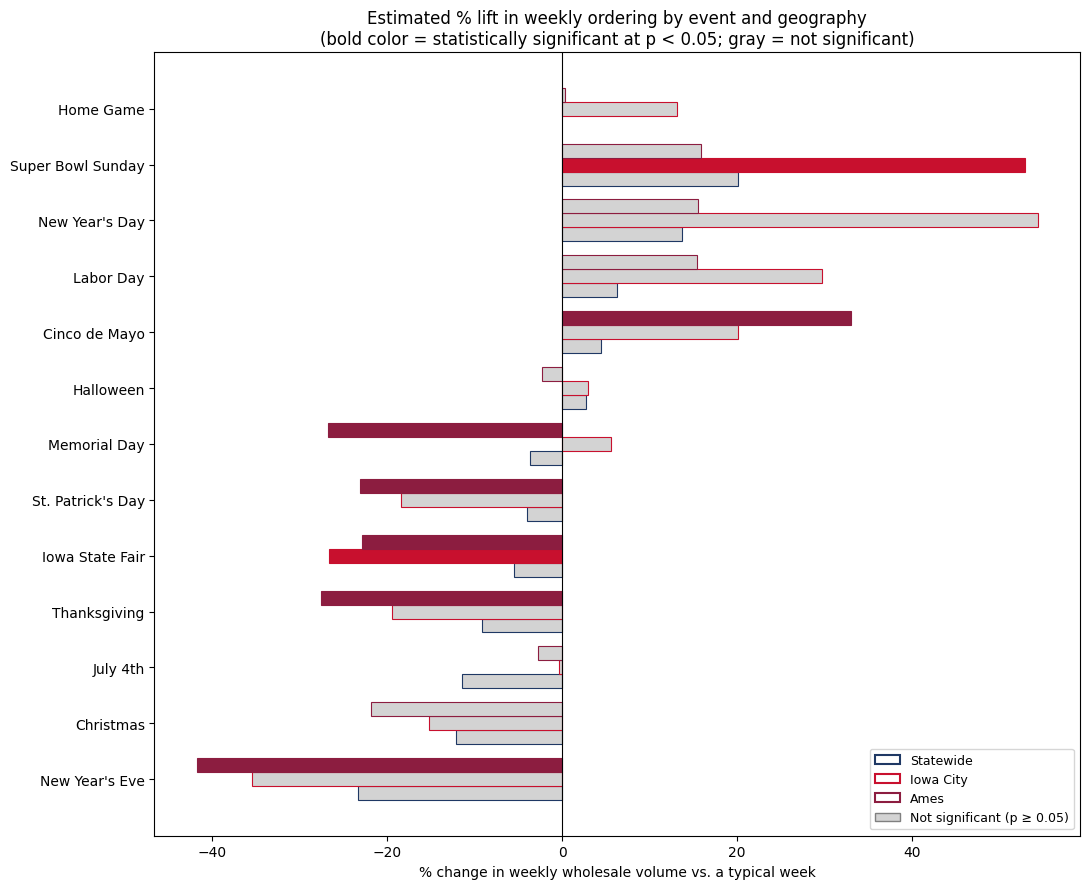

In [6]:
geo_results = {
    "Statewide": results_state,
    "Iowa City": results_iowacity.rename(index={"home_game": "Home Game"}),
    "Ames": results_ames.rename(index={"home_game": "Home Game"}),
}

all_events = list(EVENT_TYPES) + ["Home Game"]
sort_key = results_state["pct_lift"].reindex(EVENT_TYPES)
order = sort_key.sort_values(ascending=True).index.tolist() + ["Home Game"]

geo_colors = {"Statewide": "#1f3864", "Iowa City": "#c8102e", "Ames": "#8c1d40"}
bar_height = 0.25
y_positions = np.arange(len(order))

fig, ax = plt.subplots(figsize=(11, 9))

for i, (geo, results) in enumerate(geo_results.items()):
    offsets = y_positions + (i - 1) * bar_height
    lifts = results["pct_lift"].reindex(order)
    pvals = results["p_value"].reindex(order)
    colors = [geo_colors[geo] if (pd.notna(p) and p < 0.05) else "lightgray" for p in pvals]
    mask = lifts.notna()
    ax.barh(offsets[mask], lifts[mask], height=bar_height, color=np.array(colors)[mask],
            edgecolor=geo_colors[geo], linewidth=0.8)

ax.set_yticks(y_positions)
ax.set_yticklabels(order)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("% change in weekly wholesale volume vs. a typical week")
ax.set_title("Estimated % lift in weekly ordering by event and geography\n"
              "(bold color = statistically significant at p < 0.05; gray = not significant)")

legend_handles = [mpatches.Patch(facecolor="white", edgecolor=c, label=g, linewidth=1.5)
                  for g, c in geo_colors.items()]
legend_handles.append(mpatches.Patch(facecolor="lightgray", edgecolor="gray", label="Not significant (p ≥ 0.05)"))
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("proposal_figure2_event_lift.png", dpi=150, bbox_inches="tight")
plt.show()

Both figures are also saved as standalone PNGs
(`proposal_figure1_weekly_volume.png`, `proposal_figure2_event_lift.png`)
for dropping directly into the proposal document.